# Down-sampled XGBoost Confidence Regression

BSD10k?? confidence 1 ??? ???? confidence 2~5? ?? ??? under sampling? ? train/validation/test? ???, ?? XGBoost regression ???? ??? ??/???? ?????.

In [1]:
from pathlib import Path
import os
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, mean_absolute_error
from sklearn.model_selection import train_test_split

try:
    from xgboost import XGBClassifier, XGBRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('xgboost? ???? ?? ????. ????? `!pip install xgboost` ?? ? ?? ?????.') from exc

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / 'data').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = ROOT / 'data'
META_PATH = DATA_DIR / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_DIR = DATA_DIR / 'features' / 'clap_audio_embeddings'
TEXT_DIR = DATA_DIR / 'features' / 'clap_text_embeddings'

print('root:', ROOT)
print('metadata:', META_PATH)


root: c:\Users\solok\Desktop\Dcase baseline
metadata: c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv


In [2]:
def clean_metadata(df):
    df = df.copy()
    df['sound_id'] = df['sound_id'].astype(str).str.strip()
    df['class'] = df['class'].astype(str).str.strip()
    if 'class_idx' in df.columns:
        class_idx = df['class_idx'].astype(str).str.strip()
        keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith('99') | class_idx.str.endswith('00')))
        df = df[keep].copy()
    df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')
    df = df[df['confidence'].isin([1, 2, 3, 4, 5])].copy()
    df['confidence'] = df['confidence'].astype(int)
    return df.reset_index(drop=True)


def one_hot(values, categories):
    index = {category: idx for idx, category in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        col_idx = index.get(str(value))
        if col_idx is not None:
            arr[row_idx, col_idx] = 1.0
    return arr


def finite_float32(x):
    return np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def load_embeddings(df, audio_dir, text_dir):
    audio_rows, text_rows, kept = [], [], []
    for idx, row in df.reset_index(drop=True).iterrows():
        sound_id = str(row['sound_id'])
        audio_path = audio_dir / f'{sound_id}.npy'
        text_path = text_dir / f'{sound_id}.npy'
        if audio_path.is_file() and text_path.is_file():
            audio_rows.append(finite_float32(np.load(audio_path).reshape(-1)))
            text_rows.append(finite_float32(np.load(text_path).reshape(-1)))
            kept.append(idx)
    kept_df = df.reset_index(drop=True).iloc[kept].reset_index(drop=True).copy()
    return kept_df, finite_float32(np.vstack(audio_rows)), finite_float32(np.vstack(text_rows))


def build_feature_sets():
    meta = clean_metadata(pd.read_csv(META_PATH))
    categories = sorted(meta['class'].astype(str).unique().tolist())
    df, audio, text = load_embeddings(meta, AUDIO_DIR, TEXT_DIR)
    class_oh = one_hot(df['class'].astype(str).tolist(), categories)
    desc = df['description'] if 'description' in df.columns else pd.Series([''] * len(df))
    desc_len = desc.fillna('').astype(str).str.len().to_numpy(dtype=np.float32).reshape(-1, 1)

    x_method1 = finite_float32(np.concatenate([text, audio, class_oh], axis=1))
    x_method2 = finite_float32(np.concatenate([text, audio, class_oh, desc_len], axis=1))
    y = df['confidence'].to_numpy(dtype=np.int64)
    feature_sets = {
        'method1_text_audio_label': x_method1,
        'method2_text_audio_label_desc_len': x_method2,
    }
    return df, feature_sets, y, categories


def downsample_to_confidence1(df, feature_sets, y):
    labels = [1, 2, 3, 4, 5]
    counts = pd.Series(y).value_counts().sort_index()
    missing = [label for label in labels if counts.get(label, 0) == 0]
    if missing:
        raise ValueError(f'Missing confidence labels after embedding load: {missing}')

    target_n = int(counts.loc[1])
    if target_n <= 0:
        raise ValueError('confidence 1 sample count is zero after embedding load.')
    too_small = counts[counts < target_n]
    if not too_small.empty:
        raise ValueError(f'Some labels have fewer samples than confidence 1: {too_small.to_dict()}')

    rng = np.random.default_rng(SEED)
    selected = []
    for label in labels:
        label_idx = np.flatnonzero(y == label)
        selected.extend(rng.choice(label_idx, size=target_n, replace=False).tolist())
    selected = np.asarray(selected, dtype=np.int64)
    rng.shuffle(selected)

    sampled_df = df.iloc[selected].reset_index(drop=True).copy()
    sampled_feature_sets = {name: values[selected] for name, values in feature_sets.items()}
    sampled_y = y[selected]
    return sampled_df, sampled_feature_sets, sampled_y, counts.rename('before_downsample_count')


def make_splits(y):
    idx = np.arange(len(y))
    train_idx, temp_idx = train_test_split(idx, test_size=0.40, random_state=SEED, stratify=y)
    valid_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx])
    return train_idx, valid_idx, test_idx


def compute_metrics(y_true, y_pred_class, y_score_for_mae=None):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_class, average='macro', zero_division=0)
    mae_source = y_pred_class if y_score_for_mae is None else y_score_for_mae
    return {
        'accuracy': float(accuracy_score(y_true, y_pred_class)),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'mae': float(mean_absolute_error(y_true, mae_source)),
    }


def save_confusion(y_true, y_pred, title, out_path):
    labels = [1, 2, 3, 4, 5]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, vmin=0.0, vmax=1.0, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted confidence')
    ax.set_ylabel('True confidence')
    ax.set_xticks(range(5), labels)
    ax.set_yticks(range(5), labels)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm_norm[i, j] * 100:.1f}%', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)
    return cm, cm_norm


def save_loss_curve(evals_result, metric_name, title, out_path):
    train_values = evals_result['validation_0'][metric_name]
    valid_values = evals_result['validation_1'][metric_name]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(train_values, label=f'train {metric_name}')
    ax.plot(valid_values, label=f'validation {metric_name}')
    ax.set_title(title)
    ax.set_xlabel('Boosting round')
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)


## Down sampling and split

??? ??? ?? BSD10k ????? confidence 1? ??? ???? confidence 2, 3, 4, 5? ?? ??? ?? ?? ? train 60%, validation 20%, test 20%? stratified split???.


In [3]:
OUTPUT_DIR = ROOT / 'outputs' / 'down_sample_xgboost_confidence_regression'
REPORT_DIR = OUTPUT_DIR / 'reports'
PLOT_DIR = OUTPUT_DIR / 'plots'
PRED_DIR = OUTPUT_DIR / 'predictions'
for path in [REPORT_DIR, PLOT_DIR, PRED_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def make_regressor():
    return XGBRegressor(
        n_estimators=1600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        eval_metric='mae',
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        early_stopping_rounds=60,
    )


def fit_regressor(model, x_train, y_train, x_valid, y_valid):
    try:
        model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_valid, y_valid)], verbose=False)
    except TypeError:
        model.set_params(early_stopping_rounds=None)
        model.fit(
            x_train,
            y_train,
            eval_set=[(x_train, y_train), (x_valid, y_valid)],
            early_stopping_rounds=60,
            verbose=False,
        )
    return model


df, feature_sets, y, categories = build_feature_sets()
df, feature_sets, y, before_counts = downsample_to_confidence1(df, feature_sets, y)
train_idx, valid_idx, test_idx = make_splits(y)

print('samples after down sampling:', len(df))
print('split:', len(train_idx), len(valid_idx), len(test_idx))
print('class categories:', len(categories))

dist = pd.DataFrame({
    'given_ratio_percent': pd.Series({1: 1.0, 2: 6.9, 3: 30.1, 4: 55.0, 5: 7.0}),
    'before_downsample_count': before_counts,
    'after_downsample_count': pd.Series(y).value_counts().sort_index(),
})
dist['after_downsample_ratio_percent'] = (dist['after_downsample_count'] / dist['after_downsample_count'].sum() * 100).round(1)
display(dist)

summary_rows = []
for feature_name, x in feature_sets.items():
    print(f'\n===== {feature_name} | dim={x.shape[1]} =====')
    y_train = y[train_idx].astype(np.float32)
    y_valid = y[valid_idx].astype(np.float32)
    y_test = y[test_idx]

    model = make_regressor()
    model = fit_regressor(model, x[train_idx], y_train, x[valid_idx], y_valid)

    pred_score = np.clip(model.predict(x[test_idx]).astype(np.float32), 1.0, 5.0)
    pred_class = np.clip(np.rint(pred_score), 1, 5).astype(int)
    metrics = compute_metrics(y_test, pred_class, y_score_for_mae=pred_score)
    metrics.update({
        'feature_set': feature_name,
        'feature_dim': int(x.shape[1]),
        'model': 'XGBRegressor',
        'best_iteration': int(getattr(model, 'best_iteration', -1) if getattr(model, 'best_iteration', None) is not None else -1),
    })
    summary_rows.append(metrics)

    evals = model.evals_result()
    save_loss_curve(evals, 'mae', f'{feature_name} - XGBRegressor MAE', PLOT_DIR / f'{feature_name}_train_valid_mae.png')
    cm, cm_norm = save_confusion(y_test, pred_class, f'{feature_name} - row-normalized confusion', PLOT_DIR / f'{feature_name}_confusion_row_normalized.png')
    pd.DataFrame(cm, index=[f'true_{i}' for i in range(1, 6)], columns=[f'pred_{i}' for i in range(1, 6)]).to_csv(REPORT_DIR / f'{feature_name}_confusion_counts.csv')
    pd.DataFrame(cm_norm, index=[f'true_{i}' for i in range(1, 6)], columns=[f'pred_{i}' for i in range(1, 6)]).to_csv(REPORT_DIR / f'{feature_name}_confusion_row_normalized.csv')

    pred_out = df.iloc[test_idx][['sound_id', 'class', 'confidence']].copy()
    pred_out['predicted_confidence_score'] = pred_score
    pred_out['predicted_confidence_class'] = pred_class
    pred_out.to_csv(PRED_DIR / f'{feature_name}_test_predictions.csv', index=False)

summary = pd.DataFrame(summary_rows).sort_values(['mae', 'macro_f1'], ascending=[True, False])
summary.to_csv(REPORT_DIR / 'down_sample_xgboost_regression_summary.csv', index=False)
display(summary)


samples after down sampling: 530
split: 318 106 106
class categories: 23


,given_ratio_percent,before_downsample_count,after_downsample_count,after_downsample_ratio_percent
1,1.0,106,106,20.0
2,6.9,749,106,20.0
3,30.1,3280,106,20.0
4,55.0,6045,106,20.0
5,7.0,776,106,20.0



===== method1_text_audio_label | dim=1047 =====

===== method2_text_audio_label_desc_len | dim=1048 =====


,accuracy,macro_precision,macro_recall,macro_f1,mae,feature_set,feature_dim,model,best_iteration
0,0.283019,0.450091,0.284416,0.272191,1.020297,method1_text_audio_label,1047,XGBRegressor,272
1,0.273585,0.441930,0.274892,0.261878,1.028170,method2_text_audio_label_desc_len,1048,XGBRegressor,241


## Results

?? ???? ???? train/validation loss curve, row-normalized confusion matrix? ?????.


,accuracy,macro_precision,macro_recall,macro_f1,mae,feature_set,feature_dim,model,best_iteration
0,0.283019,0.450091,0.284416,0.272191,1.020297,method1_text_audio_label,1047,XGBRegressor,272
1,0.273585,0.441930,0.274892,0.261878,1.028170,method2_text_audio_label_desc_len,1048,XGBRegressor,241


### method1_text_audio_label

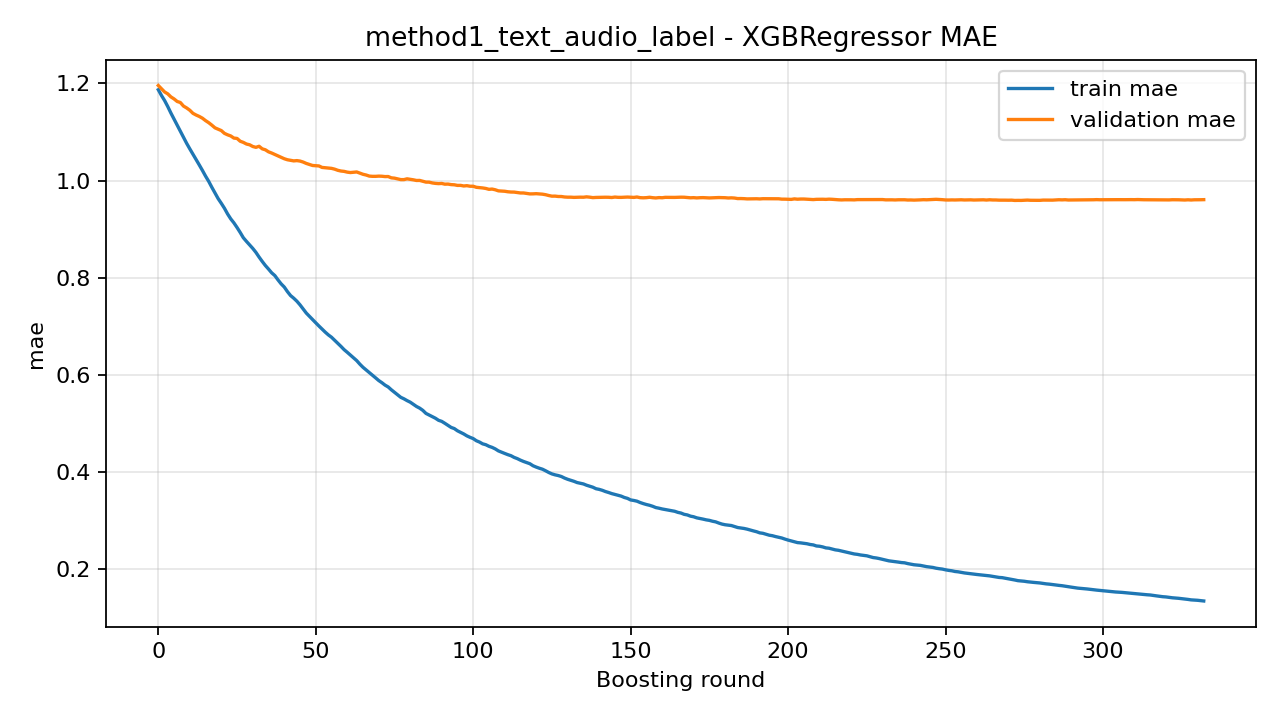

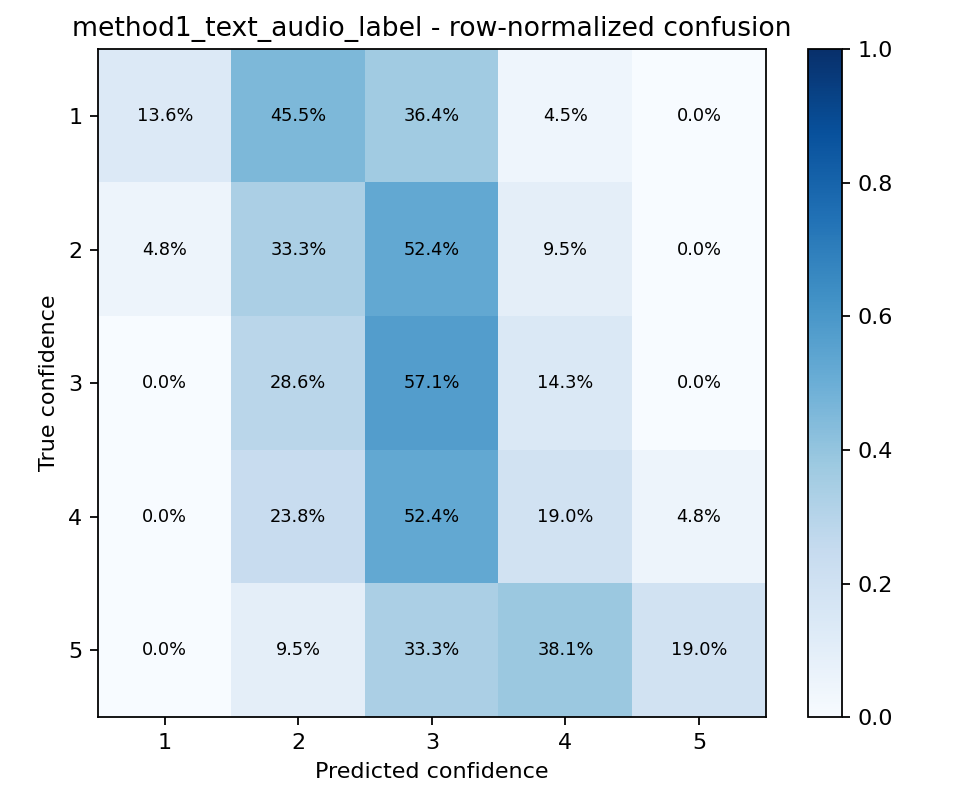

### method2_text_audio_label_desc_len

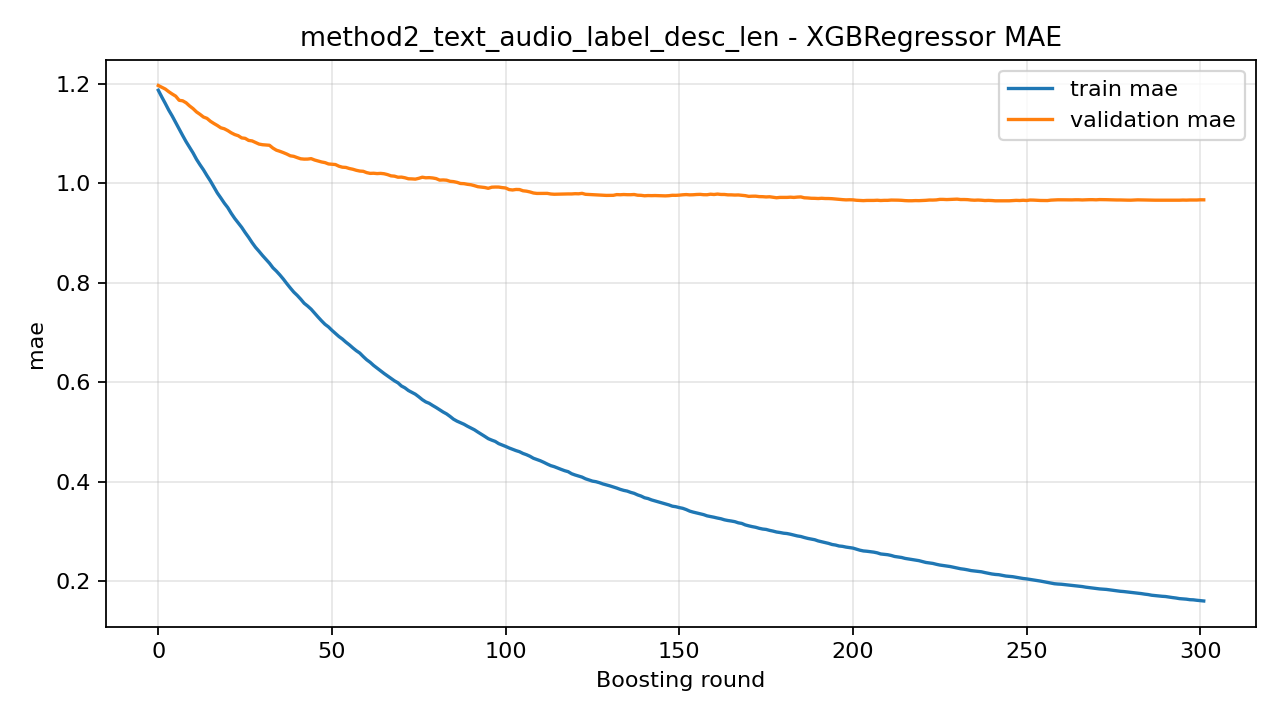

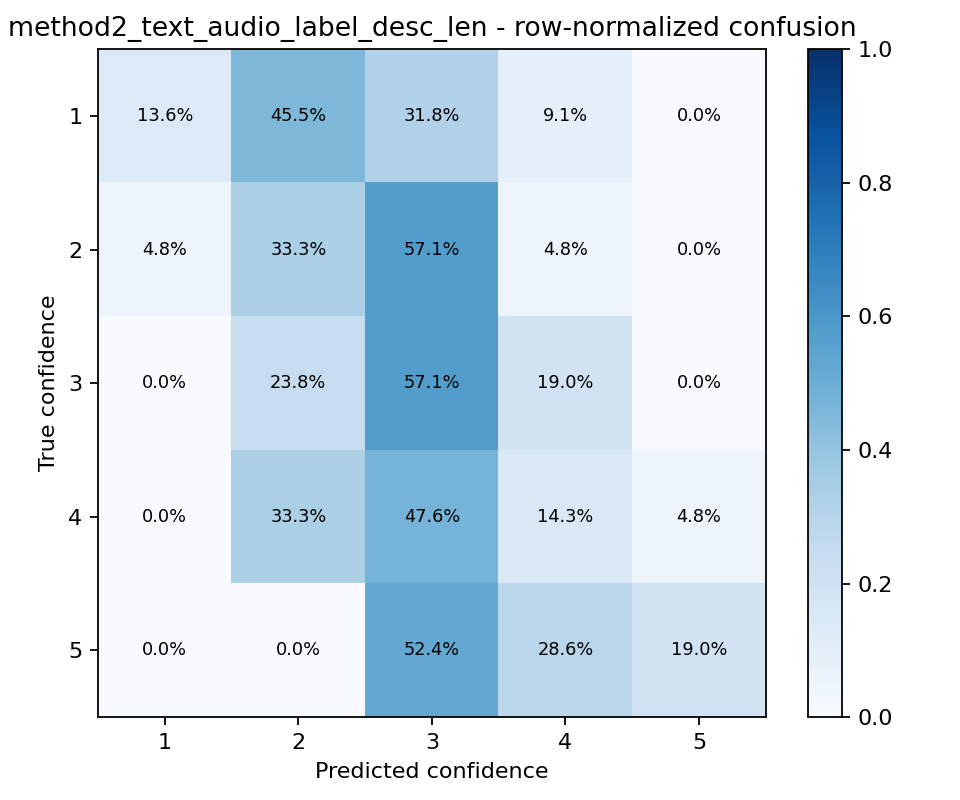

In [4]:
summary = pd.read_csv(REPORT_DIR / 'down_sample_xgboost_regression_summary.csv')
display(summary)
for feature_name in summary['feature_set']:
    display(Markdown(f'### {feature_name}'))
    display(Image(filename=str(PLOT_DIR / f'{feature_name}_train_valid_mae.png')))
    display(Image(filename=str(PLOT_DIR / f'{feature_name}_confusion_row_normalized.png')))
